In [1]:
# Load the libraries

library(vcfR)
library(ape)
library(phangorn)
library(ade4)
library(dplyr)
library(ggplot2)
library(purrr)
library(adegenet)


   *****       ***   vcfR   ***       *****
   This is vcfR 1.15.0 
     browseVignettes('vcfR') # Documentation
     citation('vcfR') # Citation
   *****       *****      *****       *****



Attaching package: ‘dplyr’


The following object is masked from ‘package:ape’:

    where


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



   /// adegenet 2.1.10 is loaded ////////////

   > overview: '?adegenet'
   > tutorials/doc/questions: 'adegenetWeb()' 
   > bug reports/feature requests: adegenetIssues()




Attaching package: ‘adegenet’


The following object is masked from ‘package:phangorn’:

    AICc




In [2]:
White_md<-read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Total_dataset_TRACwhite2011/White_1052_ctv_471inds_depthfilt_samplemd.txt", header=TRUE)

In [3]:
dapc<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/dapc_white_ward_newfilt.rds")
clus<-readRDS("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/Structure/Dapc/White_ABfilt_DAPC/clus_white_ward_newfilt.rds")

In [4]:
set.seed(10)
cols <- rainbow(length(unique(White_md$SiteCountry)))
# Create a named vector to map SiteCountry to colors
site_colors <- setNames(cols, unique(White_md$SiteCountry))

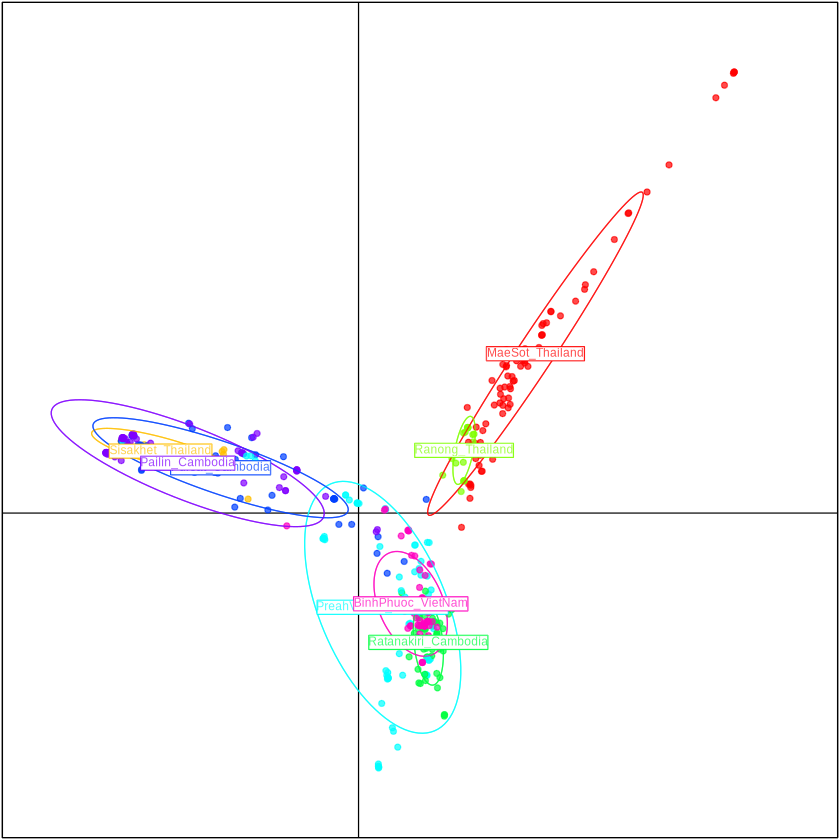

In [5]:

scatter(dapc, xax=1, yax=2, 
        grp = White_md$SiteCountry <- factor(White_md$SiteCountry, levels = c(
          "MaeSot_Thailand", "Sisakhet_Thailand", "Ranong_Thailand",
          "Ratanakiri_Cambodia", "PreahVihear_Cambodia", "Pursat_Cambodia",
          "Pailin_Cambodia", "BinhPhuoc_VietNam")),
        col = site_colors,  # Use the rainbow colors
        cstar = 0,
        clab=0.6,
        legend = F,
        #cleg=1.5,
        #posi.leg="bottomleft",
        scree.da=FALSE,
        scree.pca=FALSE)

In [ ]:
png("dapc_compoplot_clusgrp.png", width = 1000, height = 600, res = 120)
compoplot(dapc_clusgrp)
dev.off()

png 
  2

In [ ]:
# Extract individual coordinates from the DAPC object
dapc_result<-dapc

# 1. Extract individual coordinates
ind_coords <- dapc_result$ind.coord
# 2. Get group assignments
groups <- dapc_result$assign
# 3. Calculate group centers
group_centers <- dapc_result$grp.coord

# 4. Calculate distances from group centers
distances <- numeric(nrow(ind_coords))
for(i in 1:nrow(ind_coords)) {
  group <- groups[i]
  center <- group_centers[rownames(group_centers) == group,  ]
  distances[i] <- sqrt(sum((ind_coords[i,] - center)^2))
}

SiteCountry<-White_md[,"SiteCountry"]
ind_coords<-cbind(ind_coords,distances,assgn_clus=as.character(groups),Initial_SiteCountry=as.character(SiteCountry))



# 5. Determine a threshold (e.g., 1.5 times the average distance)
threshold <- 1.5 * mean(distances)

# 6. Select individuals within the threshold
selected_individuals <- which(distances <= threshold)

# 7. Create a new dataset with only the selected individuals
selected_data <-ind_coords[selected_individuals,]

print(paste0("Number of Individuals:",length(selected_data[,1])))

head(selected_data)


[1] "Number of Individuals:355"


,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry
PD0461-C,1.75211993504877,0.457521089882043,0.00806506346831889,-0.0794627982341531,0.114732673185417,0.695390430646213,Ranong_Thailand,MaeSot_Thailand
PD0462-C,2.15917213570261,1.71843933286458,-0.107433887212666,-0.0743895624576824,0.434690765544564,1.1298485496989,MaeSot_Thailand,MaeSot_Thailand
PD0467-C,1.86372366780659,0.866855882789281,-0.331314156541971,-0.178481231567399,-0.0421121709379599,0.579006571472673,Ranong_Thailand,MaeSot_Thailand
PD0470-C,2.44222883073367,2.17216193366703,0.00510533373960521,0.181729314403973,0.010754008827773,0.529429870754237,MaeSot_Thailand,MaeSot_Thailand
PD0471-C,1.92909827213579,0.916827591826682,-0.079394544041763,0.0724919770313628,-0.0116965454734301,0.642532923215943,Ranong_Thailand,MaeSot_Thailand
PD0472-C,2.41160458386969,1.72958381082593,-0.0778767827362328,-0.138970999714095,0.0659626106579697,0.934184826933355,MaeSot_Thailand,MaeSot_Thailand


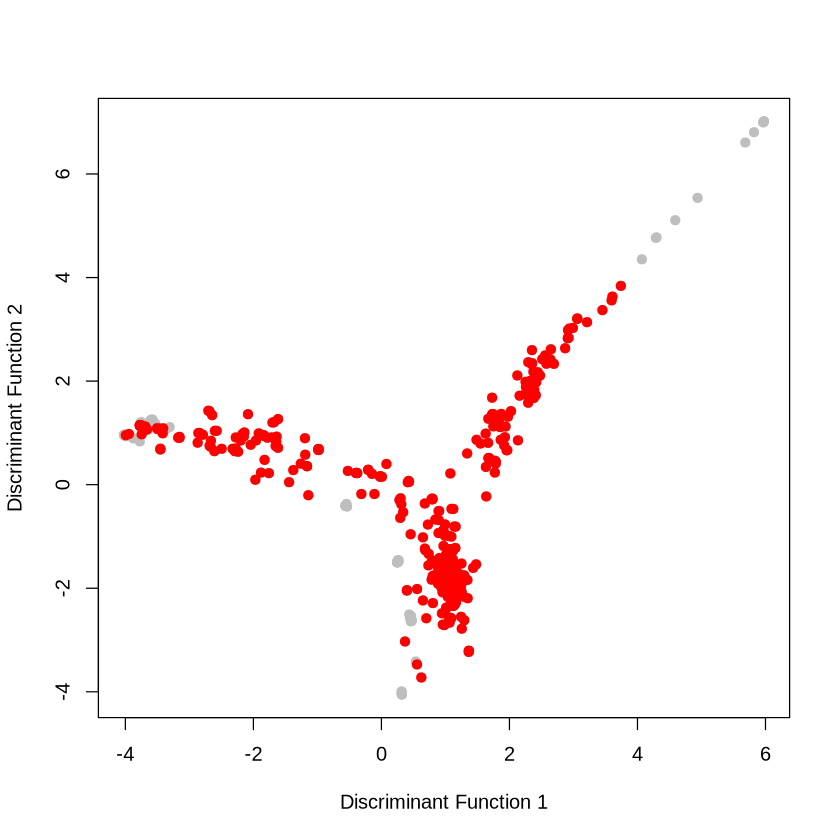

In [41]:
par(bg="white")
plot(dapc_result$ind.coord, col = "grey", pch = 19, xlab = "Discriminant Function 1", ylab = "Discriminant Function 2")
points(selected_data, col = "red", pch = 19)

In [43]:
selected_df <- as.data.frame(selected_data) %>% 
  tibble::rownames_to_column(var = "Individual") %>%
  left_join(White_md, by = c("Individual" = "Sample"))
head(selected_df)


,Individual,LD1,LD2,LD3,LD4,LD5,distances,assgn_clus,Initial_SiteCountry,Study,Site,Country,Year,ENA,Population,QC_pass,Fws,Artemisinin,SiteCountry
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<chr>,<fct>
1,PD0461-C,1.75211993504877,0.457521089882043,0.00806506346831889,-0.0794627982341531,0.114732673185417,0.695390430646213,Ranong_Thailand,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164731,WSEA,True,0.9985067,Sensitive,MaeSot_Thailand
2,PD0462-C,2.15917213570261,1.71843933286458,-0.107433887212666,-0.0743895624576824,0.434690765544564,1.1298485496989,MaeSot_Thailand,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164726,WSEA,True,0.9994090,Resistant,MaeSot_Thailand
3,PD0467-C,1.86372366780659,0.866855882789281,-0.331314156541971,-0.178481231567399,-0.0421121709379599,0.579006571472673,Ranong_Thailand,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164725,WSEA,True,0.9993150,Sensitive,MaeSot_Thailand
4,PD0470-C,2.44222883073367,2.17216193366703,0.00510533373960521,0.181729314403973,0.010754008827773,0.529429870754237,MaeSot_Thailand,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164729,WSEA,True,0.9984425,Resistant,MaeSot_Thailand
5,PD0471-C,1.92909827213579,0.916827591826682,-0.079394544041763,0.0724919770313628,-0.0116965454734301,0.642532923215943,Ranong_Thailand,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164730,WSEA,True,0.9990087,Resistant,MaeSot_Thailand
6,PD0472-C,2.41160458386969,1.72958381082593,-0.0778767827362328,-0.138970999714095,0.0659626106579697,0.934184826933355,MaeSot_Thailand,MaeSot_Thailand,1052-PF-TRAC-WHITE,MaeSot,Thailand,2011,ERR164713,WSEA,True,0.9979894,Sensitive,MaeSot_Thailand


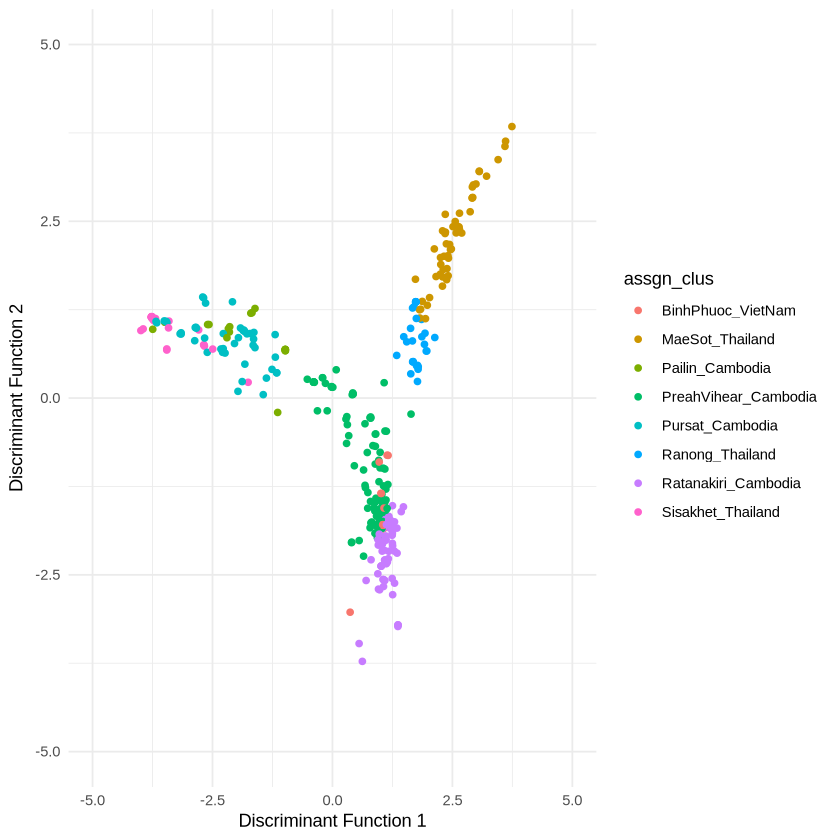

In [46]:
# If LD1 and LD2 are not numeric, convert them:
selected_df$LD1 <- as.numeric(selected_df$LD1)
selected_df$LD2 <- as.numeric(selected_df$LD2)

ggplot(selected_df, aes(x = LD1, y = LD2, color = assgn_clus)) +
  geom_point() +
  labs(x = "Discriminant Function 1", y = "Discriminant Function 2") +
  theme_minimal()+
  xlim(-5,5) +
  ylim(-5,5) # Optional: adds a clean background style


In [48]:
table(selected_df$SiteCountry)


     MaeSot_Thailand    Sisakhet_Thailand      Ranong_Thailand 
                  64                   17                   18 
 Ratanakiri_Cambodia PreahVihear_Cambodia      Pursat_Cambodia 
                  56                   52                   57 
     Pailin_Cambodia    BinhPhuoc_VietNam 
                  32                   59 

In [47]:
selected_df <- selected_df %>%
  mutate(Assgn_grp = case_when(
    SiteCountry %in% c("MaeSot_Thailand", "Ranong_Thailand") ~ "Maesot_Ranong_Thai",
    SiteCountry %in% c("Ratanakiri_Cambodia", "PreahVihear_Cambodia", "BinhPhuoc_VietNam") ~ "North_Cam_Viet",
    SiteCountry %in% c("Pursat_Cambodia", "Pailin_Cambodia", "Sisakhet_Thailand") ~ "WesternCam_SisakhetThai",
    TRUE ~ "Other"  # This is a catch-all for any groups not specified above
  ))


bycluster<- left_join(selected_df, White_md, by=c("Individual"="Sample","SiteCountry" = "SiteCountry")) %>% .[,c(-2,-3,-4)]

setwd("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/Samplemd_files/Newest_bydapcclusters_remoutliers")

write.table(bycluster, file="Allchr_Whitefullfilt_Newdapc_bycluster_md.txt", quote=FALSE, sep="\t", row.names=FALSE)
write.table(bycluster$Individual, file="Allchr_Whitefullfilt_Newdapc_bycluster_ids.txt", quote=FALSE, sep="\t", row.names=FALSE)



In [ ]:
Top20 <- bycluster %>%
  group_by(Assgn_grp) %>%               # Group by SiteCountry
  arrange(distances) %>%                   # Arrange by distances in ascending order within each group
  slice_head(n = 20)  
# Save each Assgn_grp subset as a separate text file
Top20 %>%
  group_split(Assgn_grp) %>%                        # Split by Assgn_grp
  walk(~ write.table(.x, 
                     file = paste0(unique(.x$Assgn_grp), "_Top20.txt"), 
                     sep = "\t", 
                     row.names = FALSE, 
                     quote = FALSE))

Top20 %>%
  group_split(Assgn_grp) %>%                        # Split by Assgn_grp
  walk(~ write.table(.x[,1], 
                     file = paste0(unique(.x$Assgn_grp), "_Top20_ids.txt"), 
                     sep = "\t", 
                     row.names = FALSE, 
                     quote = FALSE))

Warning message:
“... is ignored in group_split(<grouped_df>), please use group_by(..., .add =
TRUE) %>% group_split()”
Warning message:
“... is ignored in group_split(<grouped_df>), please use group_by(..., .add =
TRUE) %>% group_split()”


In [ ]:
highdep<-read.table("/data/proj2/home/students/u.srinivasan/Plasmodium_us/Inputs/VCFs/vcf_gz/vcg.gz.r3/vcfs_w_newmissfilt_newpops/Nofilt/qual_stats/individuals_to_keep.txt")


In [ ]:
all(Top20$Individual %in% highdep$V1)

[1] FALSE

In [ ]:
missing_elements <- setdiff(Top20$Individual,highdep$V1)
missing_elements

[1] "PD0459-Cx" "PH0764-C"  "PH0706-C"